In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
fake_data = "/content/drive/MyDrive/Fake News detection/Fake.csv"
true_data = "/content/drive/MyDrive/Fake News detection/True.csv"

In [45]:
fake_df = pd.read_csv(fake_data)
true_df = pd.read_csv(true_data)

In [46]:
#start with the labeling
fake_df['label'] = 0
true_df['label'] = 1

In [47]:
#before the concat check the columns for the
print(f"Fake columns : {fake_df.columns}\nTrue Columns{true_df.columns}")

print("Length of the df after concat : ", len(fake_df)+len(true_df))

Fake columns : Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')
True ColumnsIndex(['title', 'text', 'subject', 'date', 'label'], dtype='object')
Length of the df after concat :  44898


In [48]:
df = pd.concat([fake_df , true_df], axis = 0 , ignore_index= False)
print(df.shape)

(44898, 5)


In [49]:
df = df.sample(frac=1,random_state = 42).reset_index(drop=True)
print(df['label'].sample(10))
print((df['label'].value_counts(normalize=True)*100).round(2))

11276    0
7406     1
32707    0
20038    1
26389    0
8860     1
14174    1
20239    0
24277    0
27029    1
Name: label, dtype: int64
label
0    52.3
1    47.7
Name: proportion, dtype: float64


In [50]:
#Start performing the EDA first
print(df.info())
print("-"*60)
print(df.isna().sum())
print("-"*60)
print(df.describe())
print("-"*60)
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB
None
------------------------------------------------------------
title      0
text       0
subject    0
date       0
label      0
dtype: int64
------------------------------------------------------------
              label
count  44898.000000
mean       0.477015
std        0.499477
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
------------------------------------------------------------
title      object
text       object
subject    object
date       object
label       int64
dtype: object


In [51]:
df.head(5)

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


label
0    23481
1    21417
Name: count, dtype: int64
label
0    52.298543
1    47.701457
Name: proportion, dtype: float64


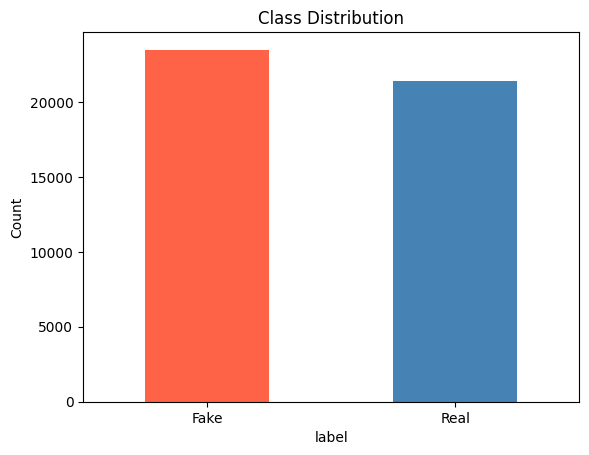

In [52]:
#checking the class imbalance
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True) * 100)

df['label'].value_counts().plot(kind='bar' , color = ['tomato','steelblue'])
plt.xticks([0,1],['Fake','Real'], rotation = 0)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()

In [53]:
#text length distribution
df['text_len']  = df['text'].apply(lambda x: len(str(x).split()))
df['title_len'] = df['title'].apply(lambda x: len(str(x).split()))

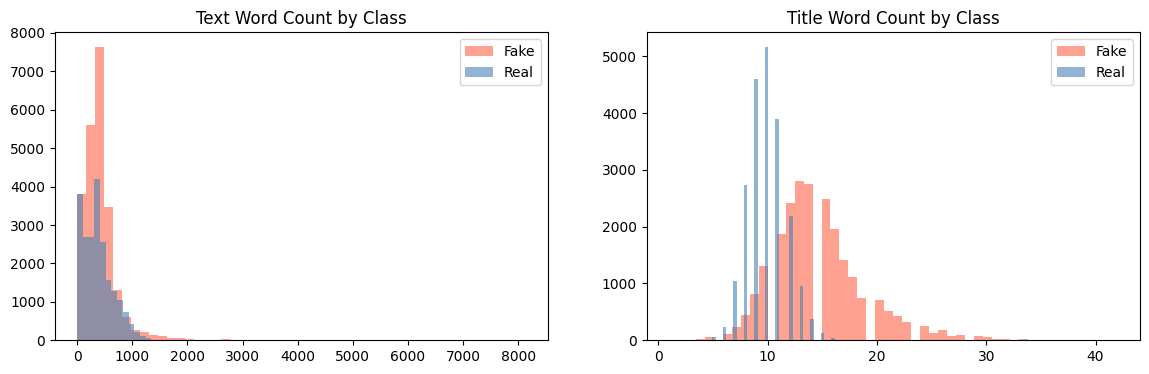

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, color in zip([0, 1], ['tomato', 'steelblue']):
    subset = df[df['label'] == label]
    axes[0].hist(subset['text_len'],  bins=50, alpha=0.6, color=color, label=['Fake','Real'][label])
    axes[1].hist(subset['title_len'], bins=50, alpha=0.6, color=color, label=['Fake','Real'][label])

axes[0].set_title('Text Word Count by Class')
axes[1].set_title('Title Word Count by Class')
for ax in axes:
    ax.legend()
plt.show()

In [55]:
#average lenght
print(df.groupby('label')[['text_len','title_len']].mean())

         text_len  title_len
label                       
0      423.197905  14.732805
1      385.640099   9.954475


In [56]:
#checking for the subject distribution
print(df['subject'].value_counts())
print("-"*70)
subject_counts = df.groupby(['subject','label']).size().unstack(fill_value=0)
print(subject_counts)

subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64
----------------------------------------------------------------------
label               0      1
subject                     
Government News  1570      0
Middle-east       778      0
News             9050      0
US_News           783      0
left-news        4459      0
politics         6841      0
politicsNews        0  11272
worldnews           0  10145


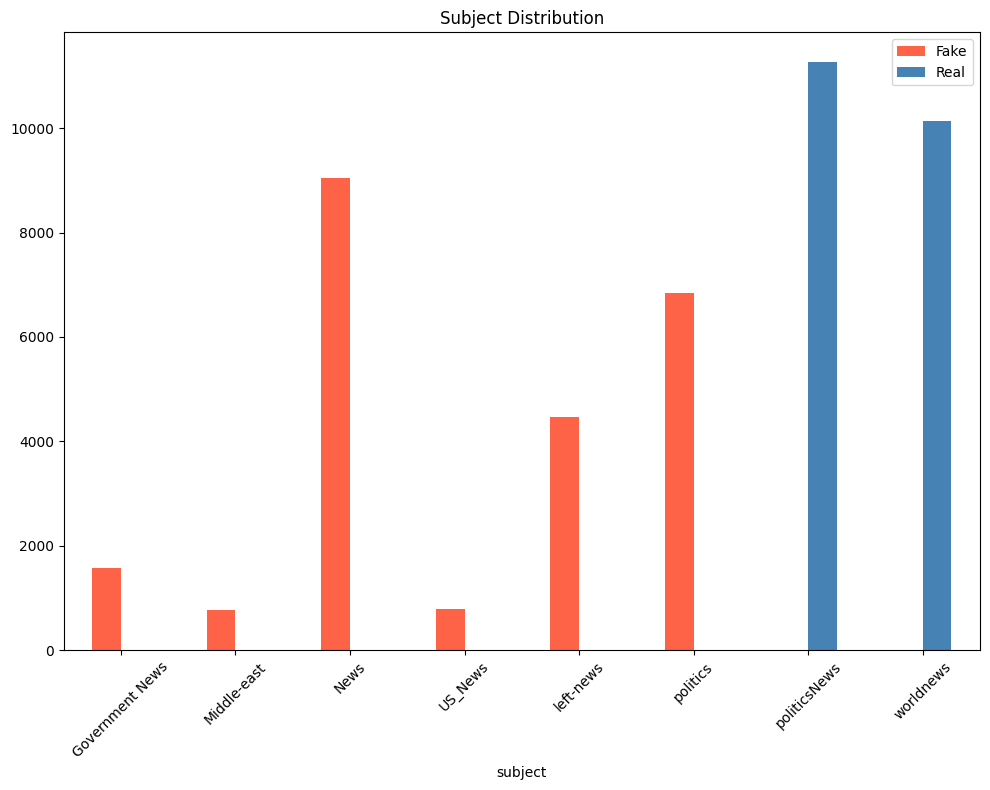

In [57]:
subject_counts.plot(kind='bar', figsize=(10,8), color=['tomato','steelblue'])
plt.title('Subject Distribution')
plt.xticks(rotation = 45)
plt.legend(['Fake', 'Real'])
plt.tight_layout()
plt.show()

In [58]:
print(fake_df['subject'].unique())
print(true_df['subject'].unique())

['News' 'politics' 'Government News' 'left-news' 'US_News' 'Middle-east']
['politicsNews' 'worldnews']


In [59]:
print(true_df['subject'].value_counts())  # i need to drop this subject later i can cause the bias in the model learning

subject
politicsNews    11272
worldnews       10145
Name: count, dtype: int64


In [60]:
#word frequency analysis
!pip install collection
from collections import Counter

In [61]:
#creating the word freq analysis

def get_top_words(df, label, col='text', n=20):
  texts = ' '.join(df[df['label'] == label][col].astype(str).str.lower())
  words = [w for w in texts.split() if len(w)>3]
  return Counter(words).most_common(n)

print("Top Fake words:", get_top_words(df, 0))
print("Top Real words:", get_top_words(df, 1))

Top Fake words: [('that', 144901), ('trump', 65511), ('with', 62025), ('this', 51753), ('have', 45626), ('they', 44822), ('from', 40324), ('about', 32073), ('their', 30164), ('what', 23849), ('will', 23730), ('would', 23261), ('been', 22811), ('people', 22359), ('president', 22080), ('were', 21368), ('said', 21221), ('when', 20982), ('more', 20020), ('just', 20005)]
Top Real words: [('that', 84922), ('said', 72035), ('with', 54074), ('from', 39189), ('u.s.', 38276), ('trump', 36485), ('have', 36176), ('would', 31361), ('will', 24921), ('president', 23399), ('said.', 21583), ('(reuters)', 21239), ('they', 20823), ('which', 20707), ('been', 19541), ('after', 19241), ('were', 18811), ('this', 18505), ('about', 17220), ('their', 16797)]


In [62]:
#world cloud
!pip install wordcloud
from wordcloud import WordCloud

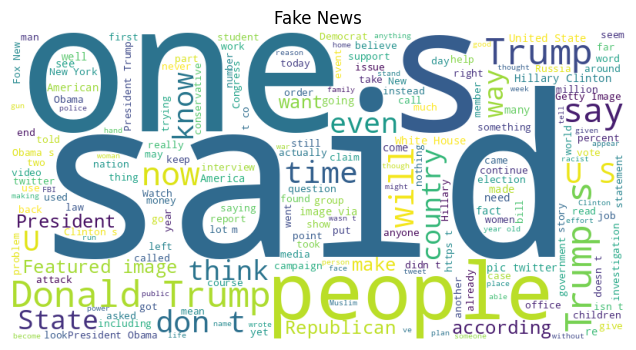

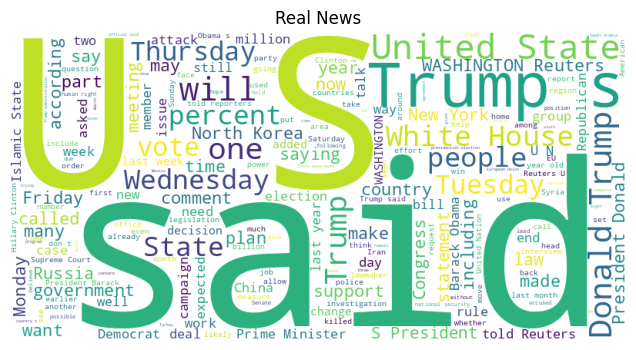

In [63]:
for label, title in zip([0, 1], ['Fake News', 'Real News']):
    text = ' '.join(df[df['label'] == label]['text'].astype(str))
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 4))
    plt.imshow(wc)
    plt.axis('off')
    plt.title(title)
    plt.show()

In [64]:
#checking for the duplicates

print(f"Duplicated terms : {df['text'].duplicated().sum()}")

#checking specific for the dataset
fake_titles = set(df[df['label']==0]['title'])
true_titles = set(df[df['label']==1]['title'])
overlap = fake_titles & true_titles

print(len(overlap))

Duplicated terms : 6252
0


In [65]:
#dropping the duplicated terms
df.drop_duplicates(subset=['text'], inplace=True)
print(f"Duplicated terms : {df['text'].duplicated().sum()}")

Duplicated terms : 0


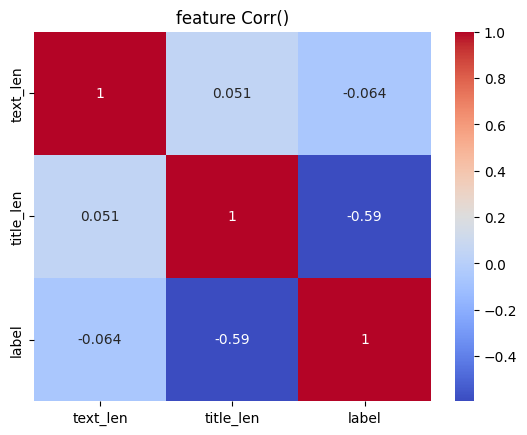

In [66]:
#finding the corr()
num_features = df[['text_len','title_len','label']]

sns.heatmap(num_features.corr(), annot = True , cmap='coolwarm')
plt.title('feature Corr()')
plt.show()

In [67]:
df.head()

,title,text,subject,date,label,text_len,title_len
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,171,14
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,771,8
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,304,10
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,183,12
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,529,10


So far the data got messy  and , it make moredifficult to train the data since we do not actually need few columns i am simply going to drop them (subject, date  , year , month)

In [68]:
#dropping the tables

df.drop(columns=['date'], inplace=True)

In [69]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 38646 entries, 0 to 44896
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   title      38646 non-null  object
 1   text       38646 non-null  object
 2   subject    38646 non-null  object
 3   label      38646 non-null  int64 
 4   text_len   38646 non-null  int64 
 5   title_len  38646 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 2.1+ MB


,0
title,0
text,0
subject,0
label,0
text_len,0
title_len,0


Now Data look more ready to train the model # first going to train the Normal Logistic CLasification Model With Out NLP

In [70]:
#making the Data Ready for the Model
data_cl = df['title'] + ' '+df['text']
print(data_cl)

0        Ben Stein Calls Out 9th Circuit Court: Committ...
1        Trump drops Steve Bannon from National Securit...
2        Puerto Rico expects U.S. to lift Jones Act shi...
3         OOPS: Trump Just Accidentally Confirmed He Le...
4        Donald Trump heads for Scotland to reopen a go...
                               ...                        
44890    Burundi opposition platform boycotts new round...
44892     Hillary’s Message To Former Miss Universe Cal...
44894    PM May seeks to ease Japan's Brexit fears duri...
44895    Merkel: Difficult German coalition talks can r...
44896     Trump Stole An Idea From North Korean Propaga...
Length: 38646, dtype: object


In [71]:
#splitting  and assigning the data
X = data_cl
y = df['label']

In [72]:
from sklearn.model_selection import train_test_split

X_train , X_test, y_train , y_test = train_test_split(X,y,test_size=0.2,stratify=y, random_state=42)

print(f"Length of X_train: {len(X_train)}")
print(f"Length of X_test: {len(X_test)}")

Length of X_train: 30916
Length of X_test: 7730


In [73]:
#creating a TF_idf vectorizer for raw and simple modeling
from sklearn.feature_extraction.text import TfidfVectorizer
model = TfidfVectorizer(
    ngram_range=(1,2),
    max_features= 50000,
    sublinear_tf= True
)
X_train_tfidf = model.fit_transform(X_train)
X_test_tfidf = model.transform(X_test)  #nevr fit on the test data can cause the data leakege

print(f"Length of Vocan: {len(model.vocabulary_)}")
print(f"Matrix shape: {X_train_tfidf.shape}")

Length of Vocan: 50000
Matrix shape: (30916, 50000)


In [74]:
#creating the Logistic regression model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight = 'balanced',
    max_iter = 1000,
    C = 1.0,
    solver = 'lbfgs'
)
lr.fit(X_train_tfidf,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [75]:
#evaluating the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_hat = lr.predict(X_test_tfidf)

print(f"Accuracy score: {accuracy_score(y_test, y_hat)}")
print(classification_report(y_test, y_hat, target_names=['Fake', 'Real']))

Accuracy score: 0.9901681759379043
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      3491
        Real       0.99      0.99      0.99      4239

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730



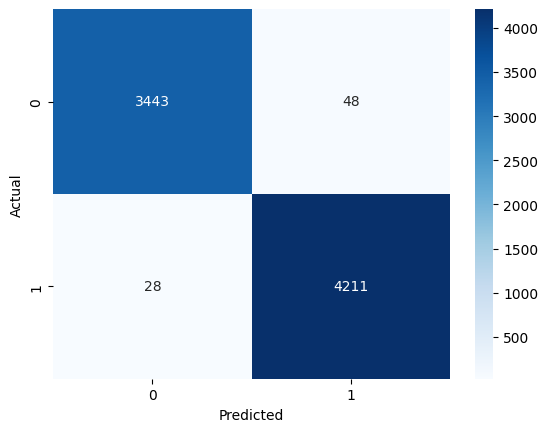

In [76]:
cm = confusion_matrix(y_test, y_hat)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [77]:
#model is highly biased or data leaked checking for the model biasness

In [78]:
fet_names = model.get_feature_names_out()
coefs = lr.coef_[0]
print("-"*60)
print("TOP REAL")
print("-"*60)
top_real = sorted(zip(coefs, fet_names),reverse=True)[:15]
for c , w in top_real:
  print(f"{w:30s} {c:.4f}")
print("-"*60)
print("TOP FAKE")
print("-"*60)
top_fake = sorted(zip(coefs,fet_names))[:15]
for c , w in top_fake:
  print(f"{w:30s} {c:.4f}")

------------------------------------------------------------
TOP REAL
------------------------------------------------------------
reuters                        16.5017
said                           9.8741
washington reuters             7.3896
said on                        6.6377
washington                     4.8144
reuters the                    4.7736
on wednesday                   4.5620
on tuesday                     4.4457
said in                        4.3806
president donald               4.3409
on thursday                    4.2494
on                             4.0642
on friday                      3.9353
said the                       3.7930
on monday                      3.7905
------------------------------------------------------------
TOP FAKE
------------------------------------------------------------
via                            -8.8763
video                          -8.2077
read more                      -5.2129
this                           -4.8479
just       

Diagnosing this using the STOPWORDS first  #adding the custom stop words

In [81]:
from sklearn.feature_extraction import text

stop_words_vocab = [
    'reuters', 'washington', 'said', 'via', 'video',
    'read', 'image', 'featured', 'watch', 'don', 'donald' , 'read more' ,'image via'
]

my_stopwords = list(text.ENGLISH_STOP_WORDS.union(stop_words_vocab))
#creating the vectorizer again
model2nd = TfidfVectorizer(
    stop_words = my_stopwords,
    ngram_range=(1,2),
    max_features= 50000,
    sublinear_tf= True
)
X_train_tfidf2 = model2nd.fit_transform(X_train)
X_test_tfidf2 = model2nd.transform(X_test)

print(f"Length of Vocab : {model2nd.vocabulary_}")
print(f"shape of the matrix ; {X_train_tfidf2.shape}")

Length of Vocab : {'star': np.int64(41587), 'young': np.int64(49856), 'popular': np.int64(33354), 'di': np.int64(12488), 'maio': np.int64(26033), 'charts': np.int64(7612), 'course': np.int64(10382), 'italy': np.int64(22442), 'pm': np.int64(32898), 'rome': np.int64(37799), 'anti': np.int64(3260), 'establishment': np.int64(14996), 'movement': np.int64(28335), 'looks': np.int64(25645), 'poised': np.int64(32953), 'luigi': np.int64(25845), 'candidate': np.int64(6841), 'prime': np.int64(34179), 'minister': np.int64(27687), 'elections': np.int64(14258), 'early': np.int64(13796), 'year': np.int64(49618), 'opinion': np.int64(30699), 'polls': np.int64(33304), 'believed': np.int64(4982), 'earnest': np.int64(13839), '31': np.int64(904), 'old': np.int64(30537), 'good': np.int64(18164), 'chance': np.int64(7472), 'winning': np.int64(49050), 'critics': np.int64(10753), 'modest': np.int64(27983), 'curriculum': np.int64(10959), 'youth': np.int64(49887), 'acknowledged': np.int64(1693), 'communication': n

In [82]:
#again building the model
LR = LogisticRegression(
    max_iter = 1000,
    class_weight = 'balanced',
    C = 1.0,
    solver = 'lbfgs',
    random_state = 42
)

LR.fit(X_train_tfidf2,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [83]:
y_pred = LR.predict(X_test_tfidf2)

print(accuracy_score(y_test, y_pred))

0.9809831824062095


In [84]:
fet_names = model2nd.get_feature_names_out()
coefs = LR.coef_[0]
print("-"*60)
print("TOP REAL")
print("-"*60)
top_real = sorted(zip(coefs, fet_names),reverse=True)[:15]
for c , w in top_real:
  print(f"{w:30s} {c:.4f}")
print("-"*60)
print("TOP FAKE")
print("-"*60)
top_fake = sorted(zip(coefs,fet_names))[:15]
for c , w in top_fake:
  print(f"{w:30s} {c:.4f}")

------------------------------------------------------------
TOP REAL
------------------------------------------------------------
wednesday                      6.7237
tuesday                        6.2858
thursday                       6.2795
friday                         5.4203
monday                         5.2451
republican                     4.6871
spokesman                      4.6377
nov                            4.6369
minister                       4.3105
statement                      4.2476
president barack               4.0407
presidential                   3.8106
democratic                     3.7103
told                           3.6001
reporters                      3.4852
------------------------------------------------------------
TOP FAKE
------------------------------------------------------------
just                           -7.9636
gop                            -6.8892
getty                          -5.8216
america                        -5.7580
obama       

In [85]:
print(df['text'])

0        21st Century Wire says Ben Stein, reputable pr...
1        WASHINGTON (Reuters) - U.S. President Donald T...
2        (Reuters) - Puerto Rico Governor Ricardo Rosse...
3        On Monday, Donald Trump once again embarrassed...
4        GLASGOW, Scotland (Reuters) - Most U.S. presid...
                               ...                        
44890    NAIROBI (Reuters) - Burundi s main opposition ...
44892    Miss Universe 1996 Alicia Machado is now an Am...
44894    LONDON/TOKYO (Reuters) - British Prime Ministe...
44895    BERLIN (Reuters) - Chancellor Angela Merkel sa...
44896    Jesus f*cking Christ our President* is a moron...
Name: text, Length: 38646, dtype: object


still the model is biased as the text is not clean and have so much of the HTML tags and data , webscraped (creating strictly for the Title to test the model )

In [88]:
#creating only on the title
print(df.head())
print(df.isnull().sum())

                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  label  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News      0   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews      1   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews      1   
3  On Monday, Donald Trump once again embarrassed...          News      0   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews      1   

   text_len  title_len  
0       171         14  
1       771          8  
2       304         10  
3       183         12  
4       529         10  
title        0
text         0
subject      0
label

In [87]:
#taking the data for the X and y trian
X = df['title']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2 , stratify =y , random_state=42)
print(len(X_train))

30916


In [109]:
#creating the vectorizr

tfidf = TfidfVectorizer(
    ngram_range = (4,6),
    max_features = None,
    sublinear_tf= True,
    analyzer = 'char'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f" Length of vocab {len(tfidf.vocabulary_)}")
print(f"Shape of matrix {X_train_tfidf.shape}")

 Length of vocab 643888
Shape of matrix (30916, 643888)


In [110]:
lr = LogisticRegression(
    class_weight = 'balanced',
    max_iter = 1000,
    C = 1.0,
    solver = 'lbfgs'
)
lr.fit(X_train_tfidf,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [111]:
y_hat = lr.predict(X_test_tfidf)

print(f"Accuracy score: {accuracy_score(y_test, y_hat)}")
print(classification_report(y_test, y_hat, target_names=['Fake', 'Real']))

Accuracy score: 0.9601552393272963
              precision    recall  f1-score   support

        Fake       0.96      0.95      0.96      3491
        Real       0.96      0.97      0.96      4239

    accuracy                           0.96      7730
   macro avg       0.96      0.96      0.96      7730
weighted avg       0.96      0.96      0.96      7730



In [112]:
fet_names = tfidf.get_feature_names_out()
coefs = lr.coef_[0]
print("-"*60)
print("TOP REAL")
print("-"*60)
top_real = sorted(zip(coefs, fet_names),reverse=True)[:15]
for c , w in top_real:
  print(f"{w:30s} {c:.4f}")
print("-"*60)
print("TOP FAKE")
print("-"*60)
top_fake = sorted(zip(coefs,fet_names))[:15]
for c , w in top_fake:
  print(f"{w:30s} {c:.4f}")

------------------------------------------------------------
TOP REAL
------------------------------------------------------------
u.s.                           5.1690
u.s.                           4.8351
.s.                            4.8251
 say                           3.8503
 says                          3.7546
says                           3.6996
 says                          3.2673
says                           3.2118
a's                            3.0043
ays                            2.9693
n's                            2.4507
ump'                           2.2365
trump'                         2.2297
rump'                          2.2297
p's                            2.1979
------------------------------------------------------------
TOP FAKE
------------------------------------------------------------
ideo                           -6.5243
video                          -6.5202
vide                           -6.3799
 the                           -6.3662
the         

In [114]:
def predict_news(title):
    content = title
    vec     = tfidf.transform([content])
    pred    = lr.predict(vec)[0]
    proba   = lr.predict_proba(vec)[0]

    label = 'REAL' if pred == 1 else 'FAKE'
    confidence = proba[pred] * 100

    print(f"Prediction : {label}")
    print(f"Confidence : {confidence:.2f}%")
    print(f"Fake prob  : {proba[0]*100:.2f}%")
    print(f"Real prob  : {proba[1]*100:.2f}%")

# Test it
predict_news(
    title=" Parliamentary committee begins review of new environmental protection bill."
)

Prediction : REAL
Confidence : 89.71%
Fake prob  : 10.29%
Real prob  : 89.71%


Central bank maintains interest rates amid cooling inflation data.
Parliamentary committee begins review of new environmental protection bill.
Global trade summit concludes with agreement on maritime shipping routes.
Government officials reportedly preparing for nationwide shutdown by next month.
Leaked memo suggest new tax will be implemented without public vote.